In [9]:
import torch
import torchvision
import torchvision.transforms.v2
from torch.utils.data import DataLoader

transforms = torchvision.transforms.v2.Compose([
    torchvision.transforms.v2.Resize(224),
    torchvision.transforms.v2.Grayscale(num_output_channels=3),
    torchvision.transforms.v2.ToImage(),
    torchvision.transforms.v2.ToDtype(torch.float32, scale=True),
    torchvision.transforms.v2.Normalize((0.1307,), (0.3081,)),
])
train_ds = torchvision.datasets.MNIST(
    "mnist", train=True, download=True, transform=transforms
)
test_ds = torchvision.datasets.MNIST(
    "mnist", train=False, download=True, transform=transforms
)

train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=128, shuffle=False)

In [10]:
import os
import numpy
import scipy.special
import sklearn.metrics

def estimate_quality(
    y_pred_logits: numpy.ndarray, y_true: numpy.ndarray
) -> dict:
    y_pred_proba = scipy.special.softmax(y_pred_logits, axis=1)
    y_pred = numpy.argmax(y_pred_proba, axis=1)
    return {
        "Accuracy": sklearn.metrics.accuracy_score(y_true, y_pred),
        "AUC-ROC": sklearn.metrics.roc_auc_score(
            y_true, y_pred_proba, multi_class="ovo"
        ),
        "Precision": sklearn.metrics.precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Recall": sklearn.metrics.recall_score(
            y_true, y_pred, average="macro"
        ),
        "F1-score": sklearn.metrics.f1_score(
            y_true, y_pred, average="macro"
        ),
        "TOP-5 Accuracy": sklearn.metrics.top_k_accuracy_score(
            y_true, y_pred_proba, k=5
        )
    }

def set_random_seed(seed: int = 42):
    numpy.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

In [11]:
import tqdm
import torchvision.models

device = torch.device('mps')

def train_eval(model: torch.nn.Module, head: torch.nn.Module, epochs: int = 5):
    set_random_seed(42)
    model = model.to(device).eval()
    head = head.to(device)
    optimizer = torch.optim.AdamW(head.parameters())

    # pbar = tqdm.trange(epochs)
    pbar = range(epochs)
    history = []
    for epoch in pbar:
        head.train()
        for X, y in tqdm.tqdm(train_dl):
            optimizer.zero_grad()
            with torch.no_grad():
                X = model(X.to(device))
            pred = head(X)
            loss = torch.nn.functional.cross_entropy(pred, y.to(device))
            loss.backward()
            optimizer.step()

        head.eval()
        test_preds, test_targets = [], []
        for X, y in test_dl:
            test_targets.extend(y.tolist())
            with torch.no_grad():
                test_preds.extend(head(model(X.to(device))).cpu().tolist())
        metrics = estimate_quality(
            numpy.array(test_preds), numpy.array(test_targets)
        )
        print(metrics)
        # pbar.set_postfix(metrics)
        history.append(metrics)
    return history

In [29]:
model = torchvision.models.vit_b_16(
    num_classes = 1000,
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
)
head = torch.nn.Linear(1000, 10)

train_eval(model, head)

100%|██████████| 469/469 [12:19<00:00,  1.58s/it]


{'Accuracy': 0.9573, 'AUC-ROC': 0.998709285234438, 'Precision': 0.9565740195762229, 'Recall': 0.9569283352644664, 'F1-score': 0.9563983870639066, 'TOP-5 Accuracy': 0.9994}


100%|██████████| 469/469 [12:23<00:00,  1.59s/it]


{'Accuracy': 0.9648, 'AUC-ROC': 0.9990979675415991, 'Precision': 0.9646956546878915, 'Recall': 0.9639411647093554, 'F1-score': 0.9641333291431078, 'TOP-5 Accuracy': 0.9996}


  0%|          | 1/469 [00:03<24:39,  3.16s/it]


KeyboardInterrupt: 

In [12]:
model = torchvision.models.vit_l_32(
    num_classes = 1000,
    weights = torchvision.models.ViT_L_32_Weights.DEFAULT
).to(device)
model.eval()

VisionTransformer(
  (conv_proj): Conv2d(3, 1024, kernel_size=(32, 32), stride=(32, 32))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=4096, out_features=1024, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
       

In [13]:
trgt_res = []
for X, y in tqdm.tqdm(test_dl):
    with torch.no_grad():
        trgt_res.append(model(X.to(device)))
trgt_res = torch.concat(trgt_res)
trgt_res.shape

100%|██████████| 79/79 [01:29<00:00,  1.13s/it]


torch.Size([10000, 1000])

In [15]:
res = []
hidden_states = []
for X, y in tqdm.tqdm(test_dl):
    with torch.no_grad():
        # Reshape and permute the input tensor
        x = model._process_input(X.to(device))
        n = x.shape[0]

        # Expand the class token to the full batch
        batch_class_token = model.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)

        torch._assert(x.dim() == 3, f"Expected (batch_size, seq_length, hidden_dim) got {x.shape}")
        x = x + model.encoder.pos_embedding
        x = model.encoder.dropout(x)
        for i, layer in enumerate(model.encoder.layers):
            if len(hidden_states) <= i:
                hidden_states.append([])
            x = layer(x)
            hidden_states[i].append(x.detach().cpu()[:, -1, :])
        x = model.encoder.ln(x)

        # Classifier "token" as used by standard language architectures
        x = x[:, 0]

        res.append(model.heads(x))

res = torch.concat(res)
for i in range(len(hidden_states)):
    hidden_states[i] = torch.concat(hidden_states[i])
hidden_states = torch.stack(hidden_states)
assert (res == trgt_res).all()

100%|██████████| 79/79 [02:11<00:00,  1.67s/it]


In [16]:
import gc
torch.mps.empty_cache()
gc.collect()

1134

Generating simplex tree without labels


100%|██████████| 24/24 [00:54<00:00,  2.28s/it]


[======================================================================] 100%


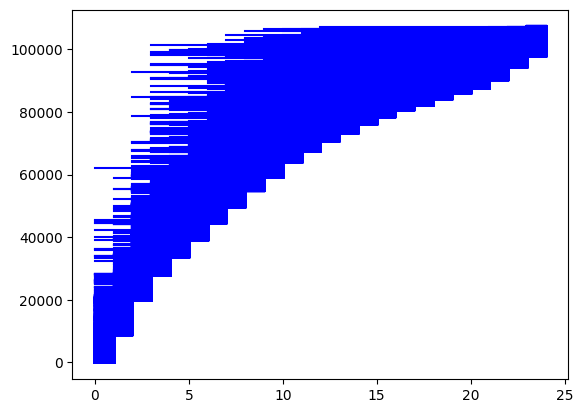

In [43]:
import dionysus
from utils.topological_analyzer import TopologicalAnalyzer

bars = TopologicalAnalyzer.compute_zigzag_barcodes(hidden_states, {"knn": 4, "dim": 5})
dionysus.plot.plot_bars(bars['diagrams'][1])

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import utils.post_process as post_process
from utils.post_process import POSTPROCESS
import pandas as pd
import os
import glob

hex6 = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000']
colors6=[mcolors.to_rgb(i) for i in hex6]

colors = ['white', colors6[2]]
positions = [0, 1]
cmap0 = mcolors.LinearSegmentedColormap.from_list("", list(zip(positions, colors)))

cb_palette = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000', '#3CAB20', '#6B750C', '#A6761D', '#D8A21E', '#F0E442',
              '#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD', '#8C564B', '#E377C2', '#7F7F7F', '#BCBD22', '#17BECF']

num_layers = hidden_states.shape[0]

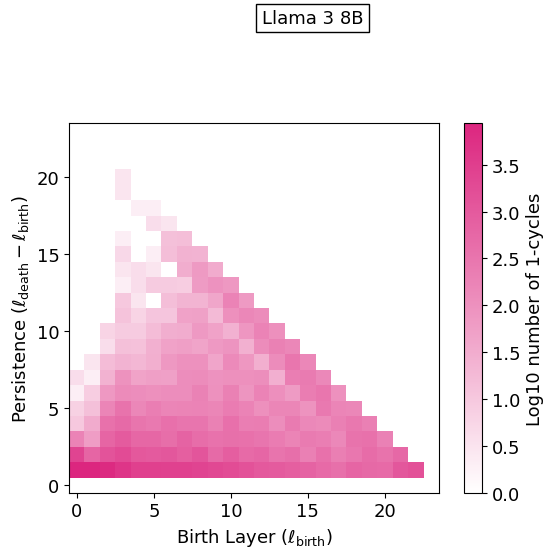

In [38]:
pp = POSTPROCESS(pds = bars['raw_diagrams'], num_layers = num_layers*2, start_ind = 1, zigzag = True, debug = False)
pis = pp.find_eff_pis()[1]
bettis = pp.find_betti_layers()[1]
import warnings
warnings.filterwarnings('ignore')
pis_pers = np.zeros((len(pis),num_layers,num_layers))
for i in range(num_layers):
    for j in range(num_layers):
        if i-j>=0:
            pis_pers[:,i-j,j] = pis[i,j]


plt.imshow(np.log10(pis_pers[1]), cmap=cmap0, origin='lower')
cb = plt.colorbar()
cb.set_label('Log10 number of 1-cycles',fontsize=13)
cb.ax.tick_params(labelsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('Birth Layer $(\\ell_{\\rm birth})$',fontsize=13)
plt.ylabel('Persistence $(\\ell_{\\rm death} - \\ell_{\\rm birth})$',fontsize=13)
plt.text(12,30,'Llama 3 8B',fontsize=13,bbox=dict(facecolor='white', edgecolor='black', boxstyle='square'))
plt.show()

In [31]:
def inter_layer_persistance(raw_diagrams,num_layers,p=1):
    pp = POSTPROCESS(pds = raw_diagrams, num_layers = num_layers*2, start_ind = 1, zigzag = True, debug = False)
    psim = pp.find_ph_sim()[p]
    bettis = pp.find_betti_layers()[p]
    temp = np.zeros((num_layers,num_layers))
    for i in range(num_layers):
        if bettis[i] == 0:
            temp[i] = 0
        else:
            temp[i] = psim[i]/bettis[i]
    return temp


def weighed_inter_layer_persistance(layer_pers,n_layers,p=1):
    weights = np.zeros((n_layers,n_layers))
    for i in range(n_layers):
        for j in range(n_layers):
                if p < 0 and i == j:
                    weights[i][j] = 1e-10
                else:
                    weights[i][j] = np.abs(i-j)**p
    return np.sum(layer_pers*weights,axis=1)/np.sum(weights,axis=1)

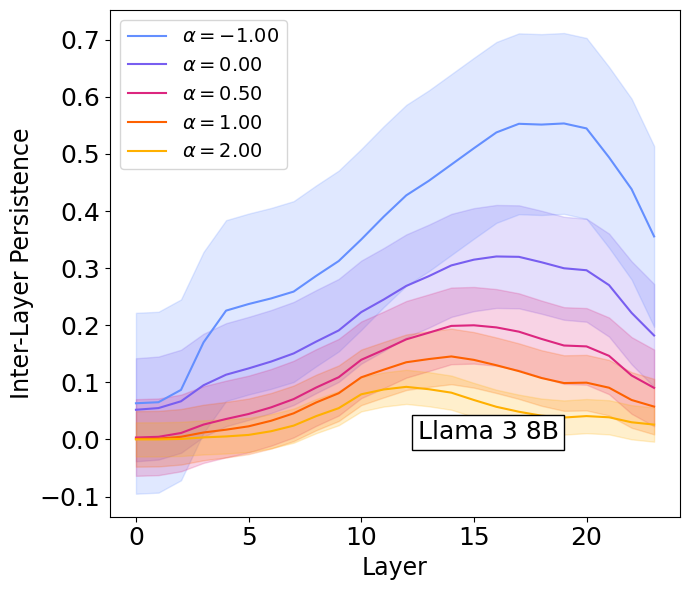

In [ ]:
plt.figure(figsize=(7, 6))
ps = [-1., 0., 0.5, 1, 2]
for p in ps:
    pers = inter_layer_persistance(bars['raw_diagrams'], num_layers)
    w_pers = weighed_inter_layer_persistance(pers, num_layers, p)

    avgsim_llama3_std = np.std(w_pers)

    x = np.arange(num_layers)
    plt.plot(x, w_pers, color=cb_palette[ps.index(p)], label='$\\alpha=%.2f$'%p)
    plt.fill_between(x, w_pers - avgsim_llama3_std, w_pers + avgsim_llama3_std, color=cb_palette[ps.index(p)], alpha=0.2)
plt.text(12.5, 0, 'Llama 3 8B', fontsize=18, bbox=dict(facecolor='white'))
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel('Layer', fontsize=17)
plt.ylabel('Inter-Layer Persistence', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

In [39]:
def effective_pi(raw_diagrams,num_layers,p=1):
    pp = POSTPROCESS(pds = raw_diagrams, num_layers = num_layers*2, start_ind = 1, zigzag = True, debug = False)
    pis = pp.find_eff_pis()[p]
    pis_pers = np.zeros((num_layers,num_layers))
    pis_death = np.zeros((num_layers,num_layers))
    for i in range(num_layers):
        for j in range(num_layers):
            if i-j>=0:
                pis_pers[i-j,j] = pis[i,j]
            pis_death[i,j] = pis[i,j]
    return pis_death

def pi_hist(model,num_layers,p=2,axis=1):
    weights = np.zeros((num_layers,num_layers))
    for i in range(num_layers):
        for j in range(num_layers):
                if p < 0 and i == j:
                    weights[i][j] = 1e-10
                else:
                    weights[i][j] = np.abs(i-j)**p
    pis = effective_pi(model,num_layers)
    pis_hist = np.sum(pis*weights,axis=axis)/np.sum(weights,axis=axis)
    # Normalize pis_hist to 1
    pis_hist /= np.sum(pis_hist)
    return pis_hist

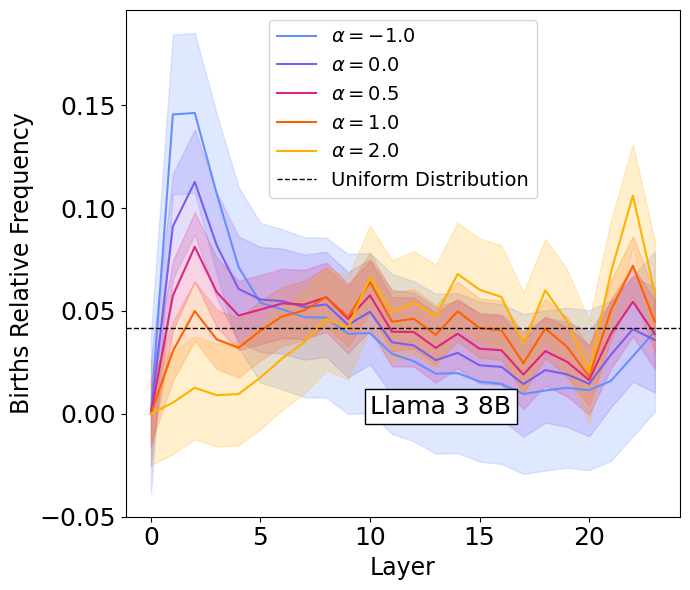

In [41]:
plt.figure(figsize=(7, 6))
ps = [-1., 0, 0.5, 1, 2]
for p in ps:  
    pi_hist500_llama3 = pi_hist(bars['raw_diagrams'], num_layers,p)
    pi_hist500_llama3_std = np.std(pi_hist500_llama3)

    x = np.arange(num_layers)
    plt.plot(x, pi_hist500_llama3, color=cb_palette[ps.index(p)], label='$\\alpha=%.1f$'%p)
    plt.fill_between(x, pi_hist500_llama3 - pi_hist500_llama3_std, pi_hist500_llama3 + pi_hist500_llama3_std, color=cb_palette[ps.index(p)], alpha=0.2)
plt.axhline(y=1/num_layers, label='Uniform Distribution',color='black', linestyle='--',lw=1)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.text(10, 0, 'Llama 3 8B', fontsize=18, bbox=dict(facecolor='white'))
plt.xlabel('Layer', fontsize=17)
plt.ylabel('Births Relative Frequency', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()